Q1. Write a unique paragraph (5-6 sentences) about your favorite topic (e.g., sports, technology, food, books, etc.).

Convert text to lowercase and remove punctuaƟon using re.
Tokenize the text into words and sentences.
Split using split() and word_tokenize() and compare how Python split and NLTK’s word_tokenize() differ.
Remove stopwords (using NLTK's stopwords list).
Display word frequency distribuƟon (excluding stopwords)

In [2]:
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
nltk.download('punkt_tab')
nltk.download('stopwords')

paragraph = """
Charizard is a powerful Fire/Flying-type Pokémon known for its dragon-like appearance and fiery breath.
It evolves from Charmeleon and is the final form of Charmander, one of the original starter Pokémon from the Kanto region.
With its strong wings, Charizard can fly at high altitudes and unleash intense flames capable of melting boulders.
Despite its fierce look, it is often loyal and protective toward its trainer.
In battles, it is admired for both its strength and its Mega Evolutions, which boost its power even further.
Charizard is one of the most iconic and beloved Pokémon in the entire franchise.
"""

# 1. Lowercase and remove punctuation
textClean = re.sub(r'[^\w\s]', '', paragraph.lower())
print("Cleaned Text:", textClean)

# 2. Tokenize sentences and words
sentTokens = sent_tokenize(paragraph)
word_tokens_nltk = word_tokenize(textClean)
word_tokens_split = textClean.split()

# 3. Compare split() vs word_tokenize()
print("Split:", word_tokens_split)
print("word_tokenize:", word_tokens_nltk)

# 4. Remove stopwords
stopWords = set(stopwords.words('english'))
filteredWords = [word for word in word_tokens_nltk if word not in stopWords]
print("Filtered Words:", filteredWords)

# 5. Word Frequency Distribution
freqDist = Counter(filteredWords)
print("Word Frequency:", freqDist)

Cleaned Text: 
charizard is a powerful fireflyingtype pokémon known for its dragonlike appearance and fiery breath 
it evolves from charmeleon and is the final form of charmander one of the original starter pokémon from the kanto region 
with its strong wings charizard can fly at high altitudes and unleash intense flames capable of melting boulders 
despite its fierce look it is often loyal and protective toward its trainer 
in battles it is admired for both its strength and its mega evolutions which boost its power even further 
charizard is one of the most iconic and beloved pokémon in the entire franchise

Split: ['charizard', 'is', 'a', 'powerful', 'fireflyingtype', 'pokémon', 'known', 'for', 'its', 'dragonlike', 'appearance', 'and', 'fiery', 'breath', 'it', 'evolves', 'from', 'charmeleon', 'and', 'is', 'the', 'final', 'form', 'of', 'charmander', 'one', 'of', 'the', 'original', 'starter', 'pokémon', 'from', 'the', 'kanto', 'region', 'with', 'its', 'strong', 'wings', 'charizard', 'c

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Q2. Using the same paragraph from Q1:

Extract all words with only alphabets using re.findall()
Remove stop words using NLTK’s stopword list
Perform stemming with PorterStemmer
Perform lemmaƟzaƟon with WordNetLemmaƟzer
Compare the stemmed and lemmaƟzed outputs and explain when you’d prefer one over the other

In [3]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('wordnet')

# 1. Extract alphabet-only words
words_alpha = re.findall(r'\b[a-zA-Z]+\b', textClean)

# 2. Remove stopwords again
filteredAlpha = [word for word in words_alpha if word not in stopWords]

# 3. Stemming
stemmer = PorterStemmer()
stemmedWords = [stemmer.stem(word) for word in filteredAlpha]

# 4. Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatizedWords = [lemmatizer.lemmatize(word) for word in filteredAlpha]

# 5. Comparison
print("Stemmed:", stemmedWords)
print("Lemmatized:", lemmatizedWords)

[nltk_data] Downloading package wordnet to /root/nltk_data...


Stemmed: ['charizard', 'power', 'fireflyingtyp', 'known', 'dragonlik', 'appear', 'fieri', 'breath', 'evolv', 'charmeleon', 'final', 'form', 'charmand', 'one', 'origin', 'starter', 'kanto', 'region', 'strong', 'wing', 'charizard', 'fli', 'high', 'altitud', 'unleash', 'intens', 'flame', 'capabl', 'melt', 'boulder', 'despit', 'fierc', 'look', 'often', 'loyal', 'protect', 'toward', 'trainer', 'battl', 'admir', 'strength', 'mega', 'evolut', 'boost', 'power', 'even', 'charizard', 'one', 'icon', 'belov', 'entir', 'franchis']
Lemmatized: ['charizard', 'powerful', 'fireflyingtype', 'known', 'dragonlike', 'appearance', 'fiery', 'breath', 'evolves', 'charmeleon', 'final', 'form', 'charmander', 'one', 'original', 'starter', 'kanto', 'region', 'strong', 'wing', 'charizard', 'fly', 'high', 'altitude', 'unleash', 'intense', 'flame', 'capable', 'melting', 'boulder', 'despite', 'fierce', 'look', 'often', 'loyal', 'protective', 'toward', 'trainer', 'battle', 'admired', 'strength', 'mega', 'evolution', '

Q3. Choose 3 short texts of your own (e.g., different news headlines, product reviews).

Use CountVectorizer to generate the Bag of Words representaƟon.
Use TfidfVectorizer to compute TF-IDF scores.
Print and interpret the top 3 keywords from each text using TF-IDF.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

texts = [
    "Pikachu stores electricity in its cheeks for battle.",
    "Bulbasaur soaks up sunlight to strengthen its plant bulb.",
    "Machop trains by lifting heavy objects to grow stronger.",
    "Pidgeotto scouts wide areas from the sky with keen vision.",
]


# 1. Bag of Words
cv = CountVectorizer()
bow = cv.fit_transform(texts)
print("BoW Features:\n", cv.get_feature_names_out())

# 2. TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)

# 3. Top 3 keywords
import numpy as np

for i, text in enumerate(texts):
    scores = tfidf_matrix[i].toarray().flatten()
    top_indices = np.argsort(scores)[-3:][::-1]
    top_words = [tfidf.get_feature_names_out()[j] for j in top_indices]
    print(f"Text {i+1} Top Keywords: {top_words}")

BoW Features:
 ['areas' 'battle' 'bulb' 'bulbasaur' 'by' 'cheeks' 'electricity' 'for'
 'from' 'grow' 'heavy' 'in' 'its' 'keen' 'lifting' 'machop' 'objects'
 'pidgeotto' 'pikachu' 'plant' 'scouts' 'sky' 'soaks' 'stores'
 'strengthen' 'stronger' 'sunlight' 'the' 'to' 'trains' 'up' 'vision'
 'wide' 'with']
Text 1 Top Keywords: ['stores', 'pikachu', 'for']
Text 2 Top Keywords: ['sunlight', 'up', 'plant']
Text 3 Top Keywords: ['stronger', 'trains', 'heavy']
Text 4 Top Keywords: ['with', 'wide', 'vision']


Q4. Write 2 short texts (4–6 lines each) describing two different technologies (e.g., AI vs Blockchain).

Preprocess and tokenize both texts.
Calculate: a. Jaccard Similarity using sets b. Cosine Similarity using TfidfVectorizer + cosine_similarity() c. Analyze which similarity metric gives beƩer insights in your case.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

text1 = "Pokémon battles are transforming how trainers grow stronger."
text2 = "Pokédex entries are changing the way trainers study each species."


# 1. Preprocess
def preprocess(text):
    text = re.sub(r'[^\w\s]', '', text.lower())
    return set(word_tokenize(text))

set1, set2 = preprocess(text1), preprocess(text2)

# 2a. Jaccard Similarity
jaccard = len(set1 & set2) / len(set1 | set2)
print("Jaccard Similarity:", jaccard)

# 2b. Cosine Similarity
tfidf = TfidfVectorizer()
tfidf_vectors = tfidf.fit_transform([text1, text2])
cosine = cosine_similarity(tfidf_vectors[0], tfidf_vectors[1])[0][0]
print("Cosine Similarity:", cosine)

Jaccard Similarity: 0.125
Cosine Similarity: 0.12735952979479354


Q5. Write a short review for a product or service.

Use TextBlob or VADER to find polarity & subjecƟvity for each review.
Classify reviews into PosiƟve / NegaƟve / Neutral.
Create a word cloud using the wordcloud library for all posiƟve reviews.

Polarity: 0.5
Subjectivity: 0.65
Sentiment: Positive


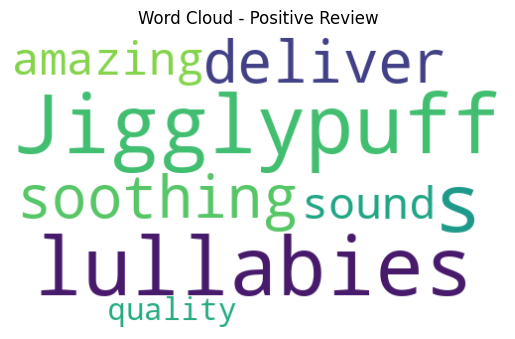

In [6]:
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt

review = "Jigglypuff’s lullabies are soothing and deliver amazing sound quality."

# 1. Sentiment
blob = TextBlob(review)
print("Polarity:", blob.sentiment.polarity)
print("Subjectivity:", blob.sentiment.subjectivity)

# 2. Classification
if blob.sentiment.polarity > 0.1:
    sentiment = "Positive"
elif blob.sentiment.polarity < -0.1:
    sentiment = "Negative"
else:
    sentiment = "Neutral"
print("Sentiment:", sentiment)

# 3. WordCloud (for positive reviews)
if sentiment == "Positive":
    wc = WordCloud(width=500, height=300, background_color='white').generate(review)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud - Positive Review")
    plt.show()

Q6. Choose your own paragraph (~100 words) as training data.

Tokenize text using Tokenizer() from keras.preprocessing.text
Create input sequences and build a simple LSTM or Dense model
Train the model and generate 2–3 new lines of text starƟng from any seed word you provide

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import numpy as np
import warnings
warnings.filterwarnings('ignore')

text = """
Sceptile is a Grass-type Pokémon known for its speed and sharp leaf blades.
It evolves from Grovyle and is the final form of Treecko, the Grass-type starter from the Hoenn region.
With its strong legs and agility, Sceptile can leap between trees effortlessly in dense forests.
The leaves on its arms are as sharp as swords, making it a fierce opponent in battle.
Sceptile is also capable of Mega Evolution, gaining a Dragon typing and enhanced offensive abilities.
It is often admired for its sleek design and strong bond with skilled trainers.
"""


# 1. Tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1

# 2. Creating n-gram sequences
input_sequences = []
words = text.lower().split()
for i in range(1, len(words)):
    n_gram_sequence = words[:i+1]
    sequence = tokenizer.texts_to_sequences([' '.join(n_gram_sequence)])[0]
    input_sequences.append(sequence)

# Padding sequence
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# 3. Model definition
model = Sequential([
    Embedding(input_dim=total_words, output_dim=10, input_length=max_len - 1),
    LSTM(50),
    Dense(total_words, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X, y, epochs=200, verbose=0)

# 4. Generate new text
seed = "ai"
for _ in range(5):
    token_seq = tokenizer.texts_to_sequences([seed])[0]
    token_seq = pad_sequences([token_seq], maxlen=max_len - 1, padding='pre')
    predicted_probs = model.predict(token_seq, verbose=0)
    predicted_index = np.argmax(predicted_probs)
    next_word = tokenizer.index_word.get(predicted_index, '')
    seed += " " + next_word

print("Generated Text:", seed)

Generated Text: ai is is is is is
